# Historic Data Analysis

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [66]:
data = pd.read_csv("../data/historic_data.csv")
data.head()

,date,latitude,longitude,elevation,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,...,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
0,2026-03-17 00:00:00+00:00,37.363796,-5.976074,15.0,14.10,47.498547,3.10,10.437123,0.0,0.0,...,86.378586,29.160000,16.85,16.90,15.40,16.95,0.176,0.343,0.404,0.293
1,2026-03-17 01:00:00+00:00,37.363796,-5.976074,15.0,13.15,50.169086,3.00,9.360641,0.0,0.0,...,76.820130,29.880000,15.95,16.85,15.40,16.95,0.176,0.343,0.404,0.293
2,2026-03-17 02:00:00+00:00,37.363796,-5.976074,15.0,12.95,53.590500,3.75,9.045335,0.0,0.0,...,78.111370,32.039997,15.20,16.70,15.40,16.95,0.166,0.343,0.427,0.293
3,2026-03-17 03:00:00+00:00,37.363796,-5.976074,15.0,12.30,57.717514,4.20,8.491515,0.0,0.0,...,69.597170,33.120000,14.50,16.60,15.45,16.95,0.166,0.343,0.427,0.293
4,2026-03-17 04:00:00+00:00,37.363796,-5.976074,15.0,11.85,56.003147,3.35,7.811231,0.0,0.0,...,65.002380,33.839996,13.85,16.45,15.45,16.95,0.167,0.343,0.427,0.293


In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           2880 non-null   object 
 1   latitude                       2880 non-null   float64
 2   longitude                      2880 non-null   float64
 3   elevation                      2880 non-null   float64
 4   temperature_2m                 2880 non-null   float64
 5   relative_humidity_2m           2880 non-null   float64
 6   dew_point_2m                   2880 non-null   float64
 7   apparent_temperature           2880 non-null   float64
 8   precipitation                  2880 non-null   float64
 9   rain                           2880 non-null   float64
 10  snowfall                       2880 non-null   float64
 11  snow_depth                     2880 non-null   float64
 12  weather_code                   2880 non-null   f

In [68]:
data["date"] = pd.to_datetime(data["date"], utc=True)

In [69]:
len(data.index), len(data.columns), np.size(data)

(2880, 34, 97920)

## Description of the features

In [70]:
data.columns

Index(['date', 'latitude', 'longitude', 'elevation', 'temperature_2m',
       'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature',
       'precipitation', 'rain', 'snowfall', 'snow_depth', 'weather_code',
       'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'et0_fao_evapotranspiration',
       'vapour_pressure_deficit', 'wind_speed_10m', 'wind_speed_100m',
       'wind_direction_10m', 'wind_direction_100m', 'wind_gusts_10m',
       'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
       'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm'],
      dtype='object')

In [71]:
data.attrs['description'] = {
    'date': 'Time and date',
    'latitude': 'Geographical WGS84 coordinates of the location. Multiple coordinates can be comma separated. E.g. &latitude=52.52,48.85&longitude=13.41,2.35. To return data for multiple locations the JSON output changes to a list of structures. CSV and XLSX formats add a column location_id. For North and South America locations use negative longitudes, because they lie west of Greenwich.',
    'longitude': 'Geographical WGS84 coordinates of the location. Multiple coordinates can be comma separated. E.g. &latitude=52.52,48.85&longitude=13.41,2.35. To return data for multiple locations the JSON output changes to a list of structures. CSV and XLSX formats add a column location_id. For North and South America locations use negative longitudes, because they lie west of Greenwich.',
    'elevation': 'The elevation used for statistical downscaling. Per default, a 90 meter digital elevation model is used. You can manually set the elevation to correctly match mountain peaks. If &elevation=nan is specified, downscaling will be disabled and the API uses the average grid-cell height. For multiple locations, elevation can also be comma separated.',
    'temperature_2m': 'Air temperature at 2 meters above ground (Celsius degrees)',
    'relative_humidity_2m': 'Relative humidity at 2 meters above ground',
    'dew_point_2m': 'Dew point temperature at 2 meters above ground (Celsius degrees)',
    'apparent_temperature': 'Apparent temperature is the perceived feels-like temperature combining wind chill factor, relative humidity and solar radiation (Celsius degrees)',
    'precipitation': 'Total precipitation (rain, showers, snow) sum of the preceding hour (mm)',
    'rain': 'Rain from large scale weather systems of the preceding hour in millimeter (mm)',
    'snowfall': 'Snowfall amount of the preceding hour in centimeters. For the water equivalent in millimeter, divide by 7. E.g. 7 cm snow = 10 mm precipitation water equivalent (cm)',
    'snow_depth': 'Snow depth on the ground (meters)',
    'weather_code': 'Weather condition as a numeric code. Follow WMO weather interpretation codes. See table below for details. (WMO code)',
    'pressure_msl': 'Atmospheric air pressure reduced to mean sea level (msl) or pressure at surface. Typically pressure on mean sea level is used in meteorology. Surface pressure gets lower with increasing elevation. (hPa)',
    'surface_pressure': 'Atmospheric air pressure reduced to mean sea level (msl) or pressure at surface. Typically pressure on mean sea level is used in meteorology. Surface pressure gets lower with increasing elevation. (hPa)',
    'cloud_cover': 'Total cloud cover as an area fraction (%)',
    'cloud_cover_low': 'Low level clouds and fog up to 3 km altitude (%)',
    'cloud_cover_mid': 'Mid level clouds from 3 to 8 km altitude (%)',
    'cloud_cover_high': 'High level clouds from 8 km altitude (%)',
    'et0_fao_evapotranspiration': 'ET₀ Reference Evapotranspiration of a well watered grass field. Based on FAO-56 Penman-Monteith equations ET₀ is calculated from temperature, wind speed, humidity and solar radiation. Unlimited soil water is assumed. ET₀ is commonly used to estimate the required irrigation for plants. (mm)',
    'vapour_pressure_deficit': 'Vapour Pressure Deficit (VPD) in kilopascal (kPa). For high VPD (>1.6), water transpiration of plants increases. For low VPD (<0.4), transpiration decreases (kPa)',
    'wind_speed_10m': 'Wind speed at 10 meters above ground. Wind speed on 10 meters is the standard level. (km/h)',
    'wind_speed_100m': 'Wind speed at 100 meters above ground. Wind speed on 10 meters is the standard level. (km/h)',
    'wind_direction_10m': 'Wind direction at 10 meters above ground (degrees)',
    'wind_direction_100m': 'Wind direction at 100 meters above ground (degrees)',
    'wind_gusts_10m': 'Gusts at 10 meters above ground as a maximum of the preceding hour (km/h)',
    'soil_temperature_0_to_7cm': 'Average temperature of different soil levels below ground.',
    'soil_temperature_7_to_28cm': 'Average temperature of different soil levels below ground.',
    'soil_temperature_28_to_100cm': 'Average temperature of different soil levels below ground.',
    'soil_temperature_100_to_255cm': 'Average temperature of different soil levels below ground.',
    'soil_moisture_0_to_7cm': 'Average soil water content as volumetric mixing ratio at 0-7 cm depth. (m^3/m^3)',
    'soil_moisture_7_to_28cm': 'Average soil water content as volumetric mixing ratio at 7-28 cm depth. (m^3/m^3)',
    'soil_moisture_28_to_100cm': 'Average soil water content as volumetric mixing ratio at 28-100 cm depth. (m^3/m^3)',
    'soil_moisture_100_to_255cm': 'Average soil water content as volumetric mixing ratio at 100-255 cm depth. (m^3/m^3)',
}

## Visualization of the features

In [72]:
import plotly.express as px

In [73]:
px.line(data, 
        x='date', y='temperature_2m',
        title='Temperature evolution',
        labels={
            'date': 'Datetime',
            'temperature_2m': 'Temperature at 2 meters'
        })


### What is happening?

The thing here is that we have different locations in the dataset. See the _latitude_ and _longitude_ features. We have many features we can use to explain our goal, which are:
1. Estimating the future temperature (regression model),
2. Estimating if it's a rainy day or not (classification model).

In order to proceed, we will select some features first, and then, when finished the model, we will add more features to study the complexity of it.

For the temperature estimation, we will select:
* temperature_2m,
* relative_humidity_2m,
* pressure_msl,
* wind_speed_10m,
* wind_direction_10m,
* cloud_cover,
* precipitation.

For the 'weather_code' classification, we will select:
* predicted temperature from previous model,
* relative_humidity_2m,
* pressure_msl,
* precipitation,
* cloud_cover,
* wind_speed_10m,
* wind_speed_100m,
* wind_direction_10m,
* wind_direction_100m,
* wind_gusts_10m

## Temperature Model

In [74]:
temp_features = ['date','latitude', 'temperature_2m', 'relative_humidity_2m',
                 'pressure_msl', 'wind_speed_10m', 'wind_direction_10m',
                 'cloud_cover', 'precipitation']
temp_data = data[temp_features]

### Feature Expansion: pivot / unstack dataset

In [75]:
locations = ['seville', 'cadiz', 'huelva', 'malaga', 'cordoba', 'badajoz', 'lisbon', 'c_real']

loc_dict = {lat: loc for (lat, loc) in zip(data['latitude'].unique(), locations)}

temp_data['zone'] = temp_data['latitude'].map(loc_dict)

/var/folders/f9/wfy__0w50fs38x4mwcl58q6h0000gn/T/ipykernel_2139/2337524417.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_data['zone'] = temp_data['latitude'].map(loc_dict)


In [76]:
wide_temp_data = temp_data.pivot_table(
    index='date',
    columns='zone',
    values=temp_features[2:],
    aggfunc='first'
)

wide_temp_data.columns = [f'{feat}_{zone}' for feat, zone in wide_temp_data.columns]
#df_wide = wide_temp_data.reset_index()

In [77]:
wide_temp_data['datetime'] = wide_temp_data.index
data_date = pd.to_datetime(wide_temp_data.index)
wide_temp_data['hour'] = data_date.hour
wide_temp_data['sin_hour'] = np.sin(2*np.pi*wide_temp_data['hour']/24)
wide_temp_data['cos_hour'] = np.cos(2*np.pi*wide_temp_data['hour']/24)

# maybe unnecessary
#wide_temp_data['dayofweek'] = data_date.dayofweek

Let's see some visualizations!

### Visualizations

Let's compare first the temperatures at 2 meters:

In [78]:
import seaborn as sns

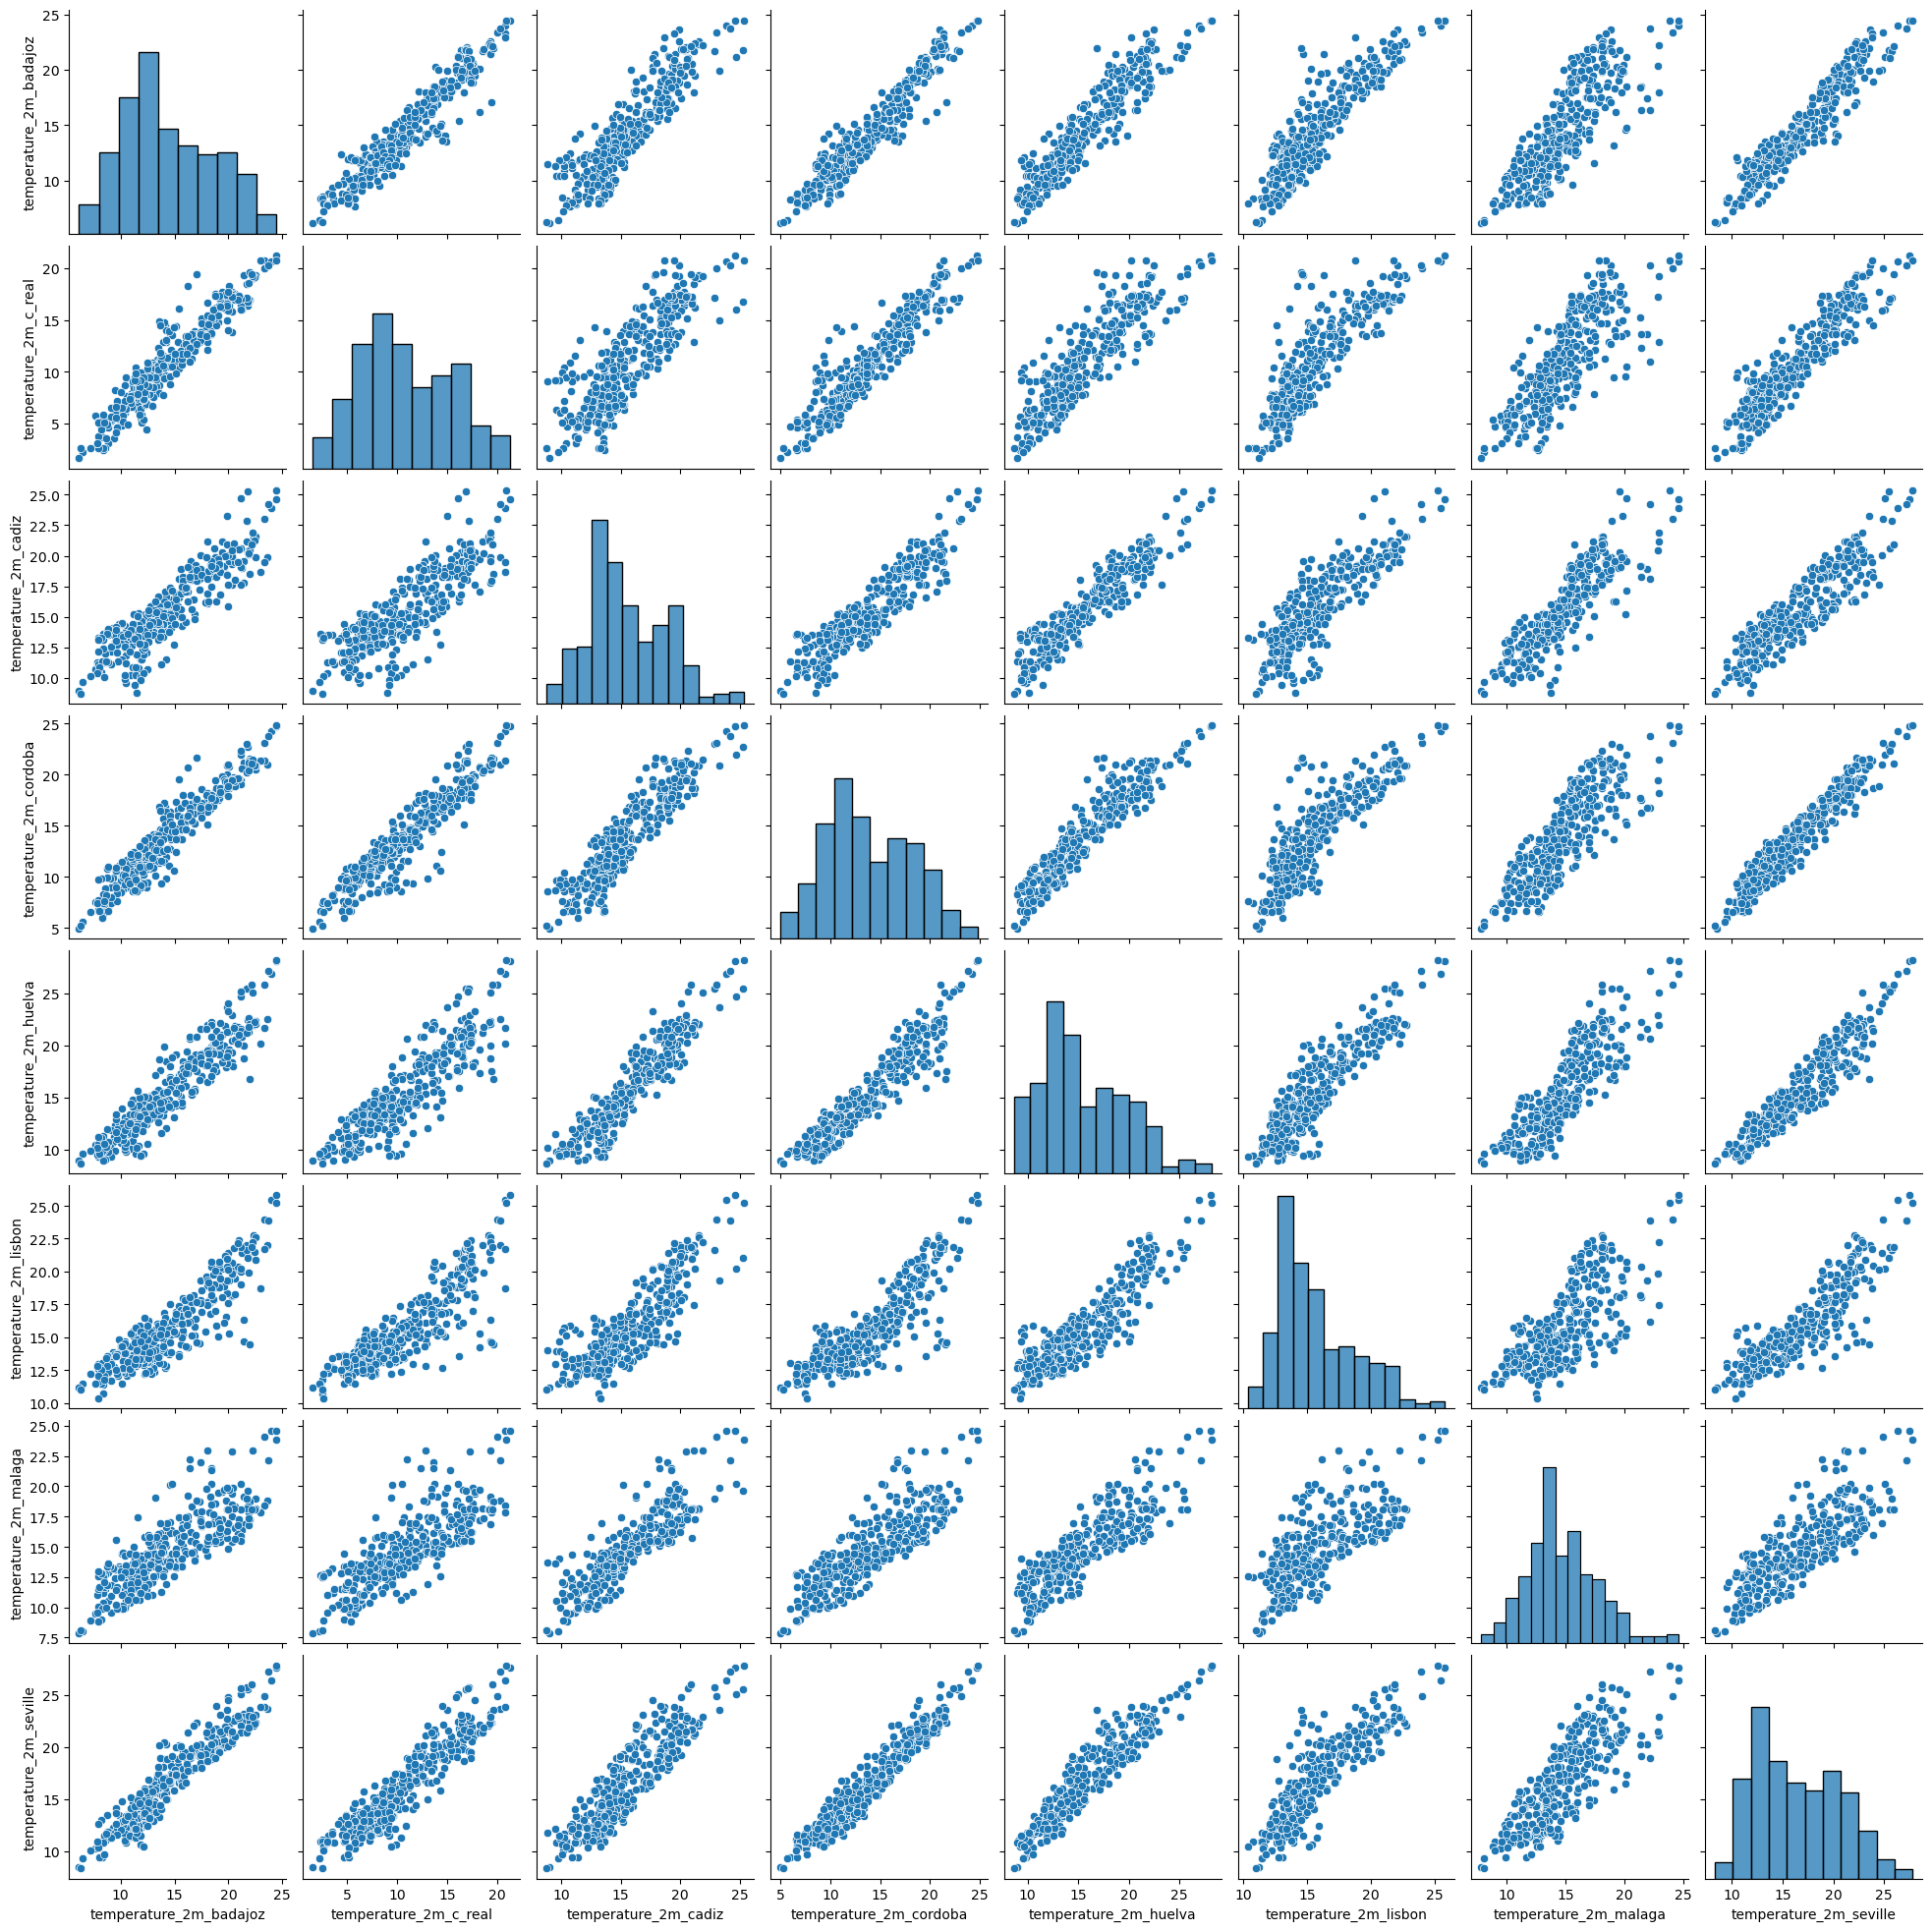

In [79]:
temps_2m = [x for x in wide_temp_data if 'temperature_2m' in x]

sns.pairplot(wide_temp_data[temps_2m], kind="scatter")
plt.show()


There is no real juice in here. We know that if temperature is higher, it will be higher in each place of the near regions...

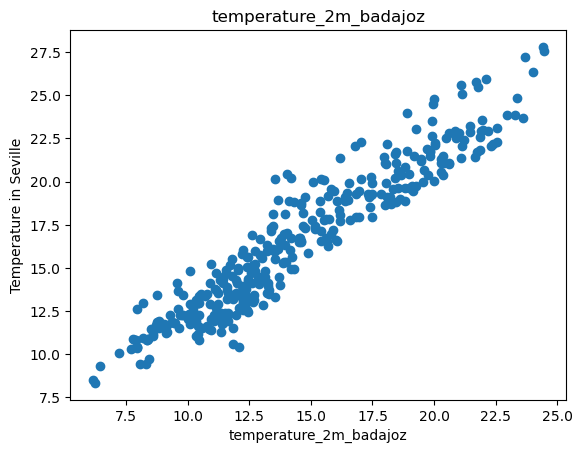

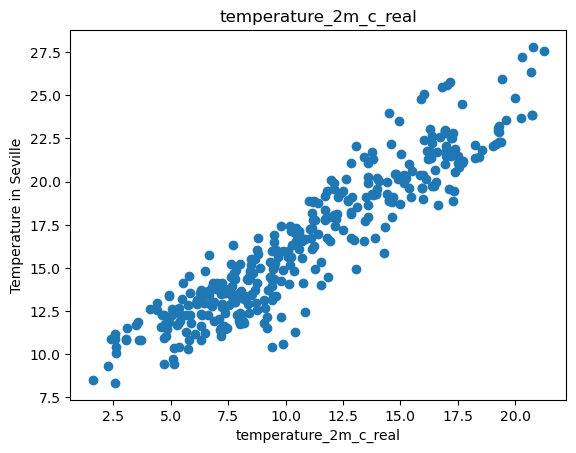

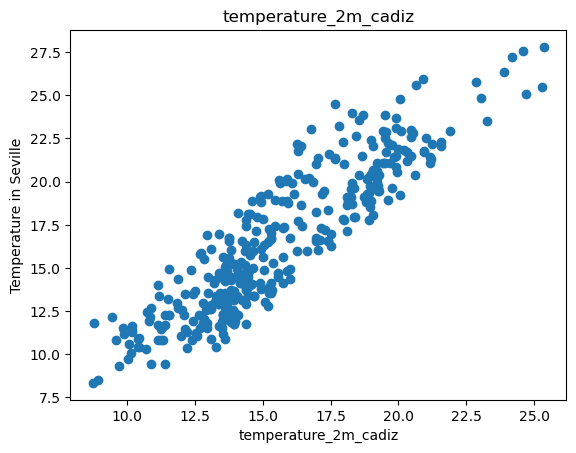

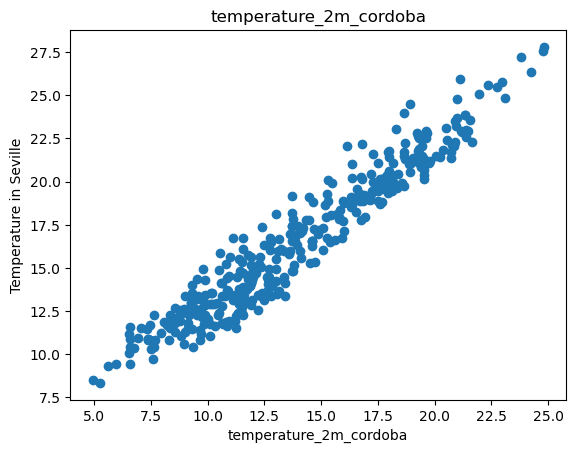

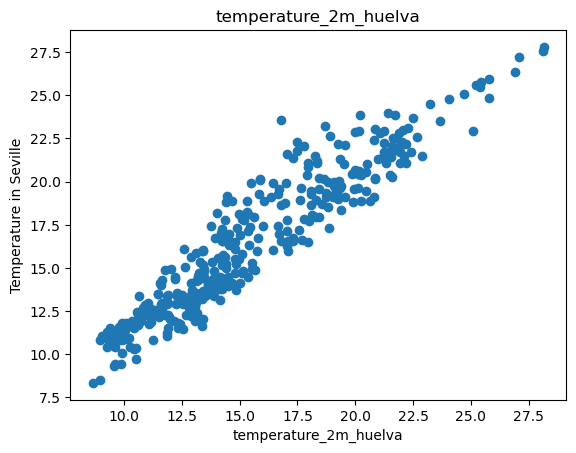

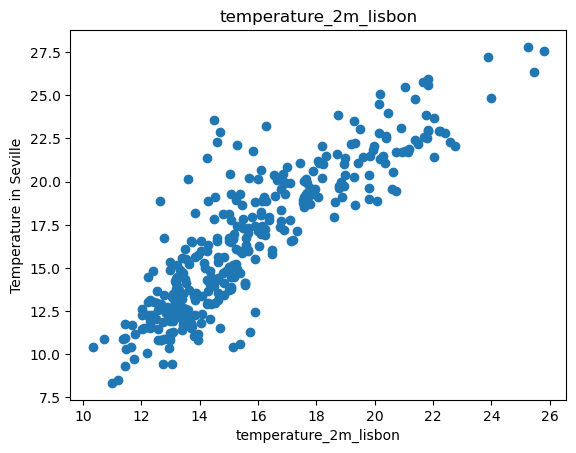

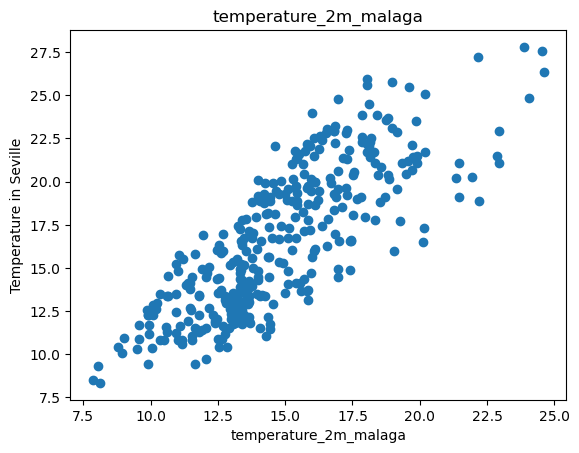

In [80]:
for label in temps_2m[:-1]:
    plt.scatter(wide_temp_data[label], wide_temp_data['temperature_2m_seville'])
    plt.title(label)
    plt.ylabel('Temperature in Seville')
    plt.xlabel(label)
    plt.show()

Let's see temperature against wind speed

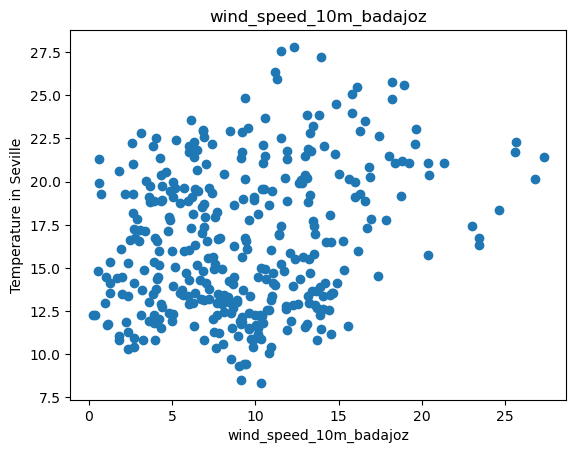

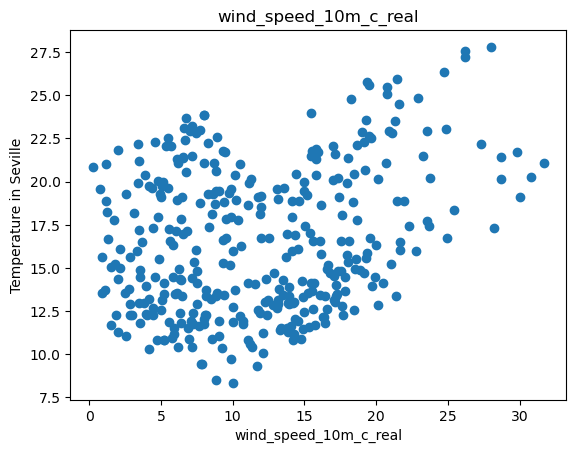

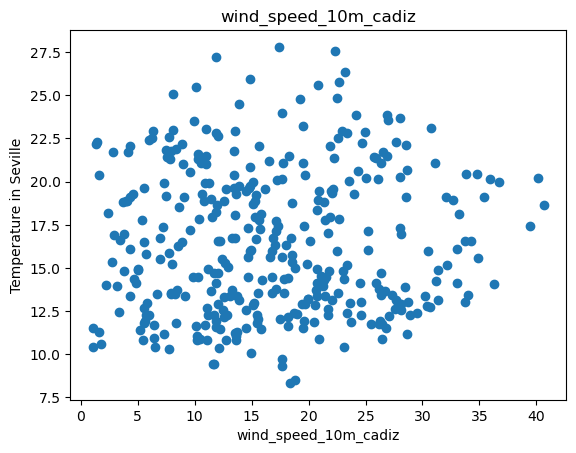

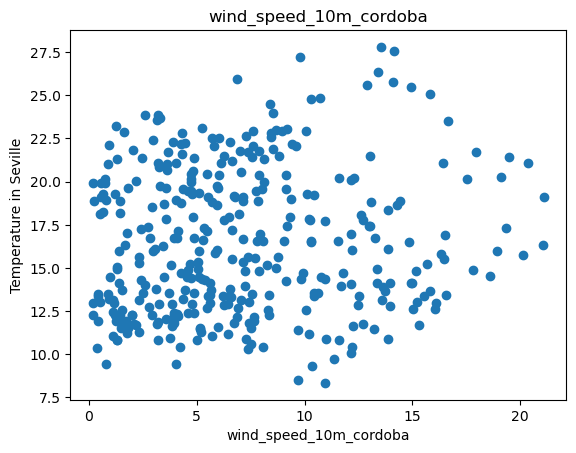

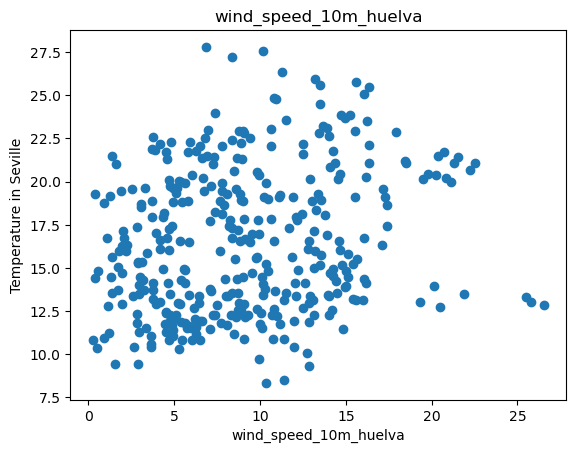

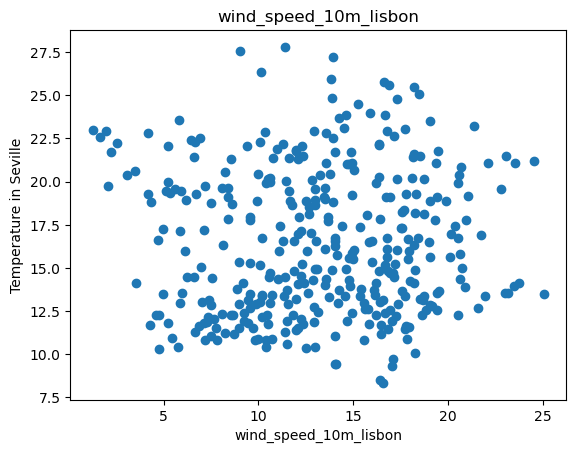

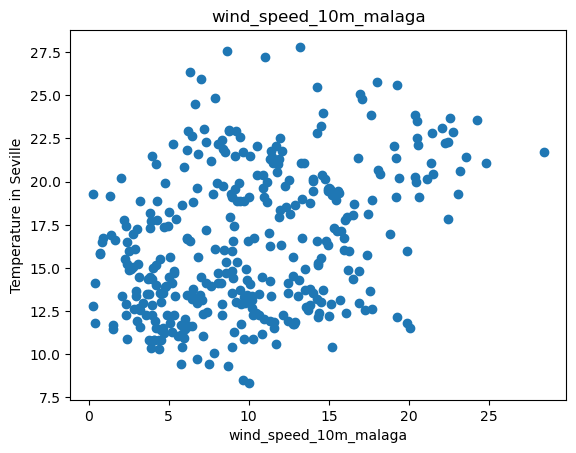

In [81]:
for label in [w for w in wide_temp_data.columns if 'wind_speed' in w and 'seville' not in w]:
    plt.scatter(wide_temp_data[label], wide_temp_data['temperature_2m_seville'])
    plt.title(label)
    plt.ylabel('Temperature in Seville')
    plt.xlabel(label)
    plt.show()

There is no apparent relation... What about the relation with precipitations

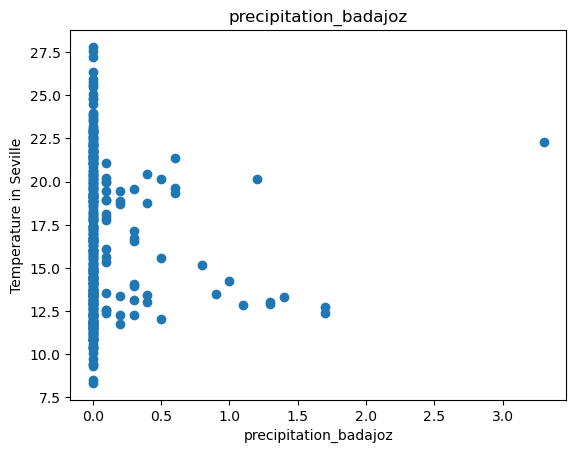

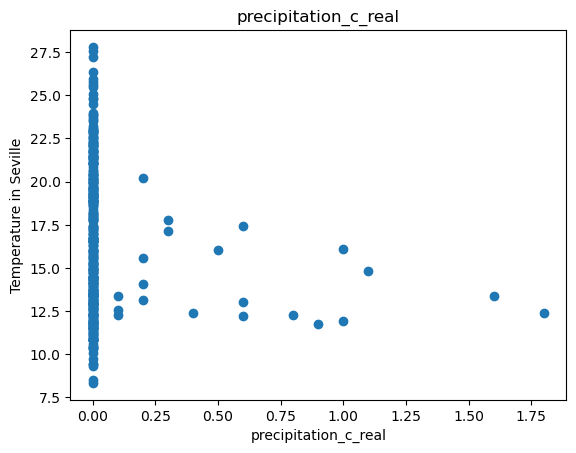

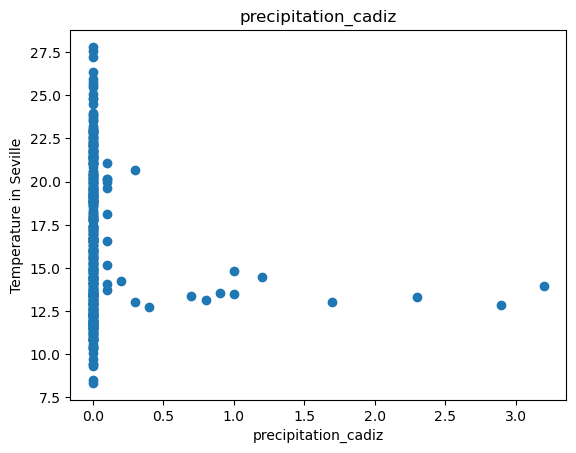

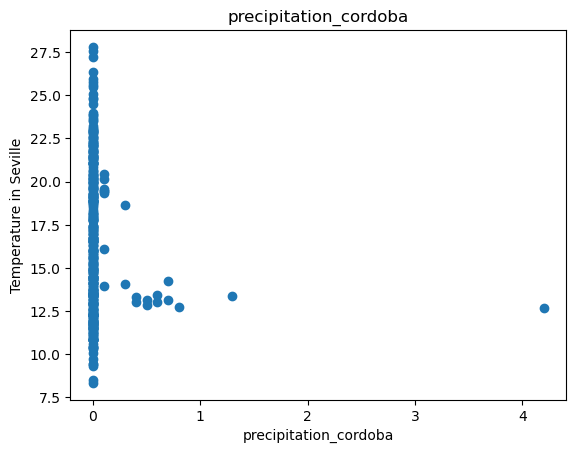

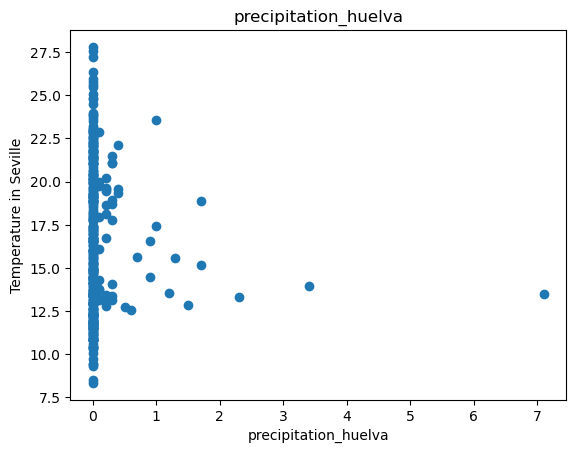

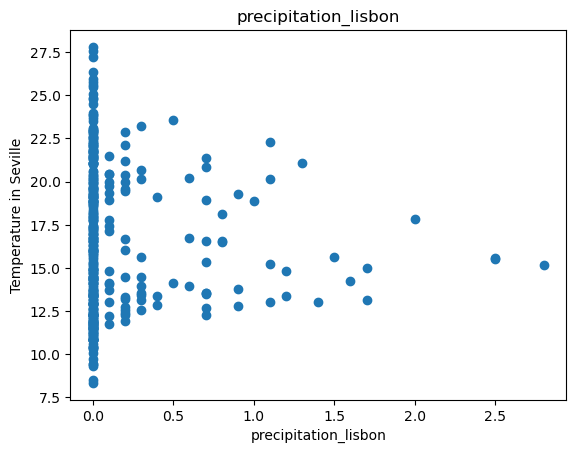

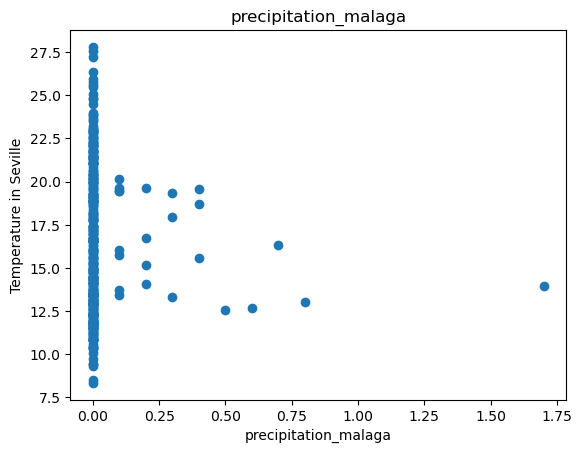

In [82]:
for label in [p for p in wide_temp_data.columns if 'precipitation' in p and 'seville' not in p]:
    plt.scatter(wide_temp_data[label], wide_temp_data['temperature_2m_seville'])
    plt.title(label)
    plt.ylabel('Temperature in Seville')
    plt.xlabel(label)
    plt.show()

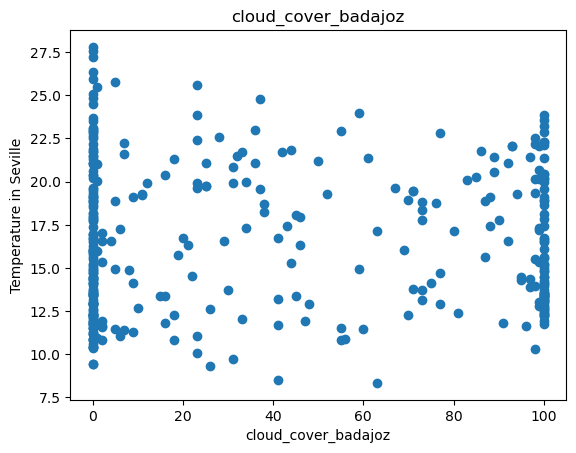

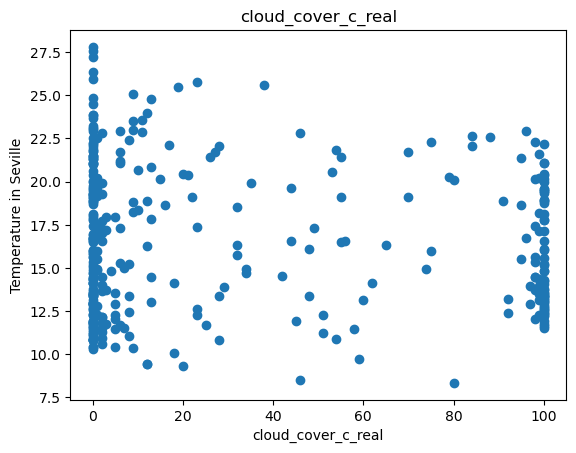

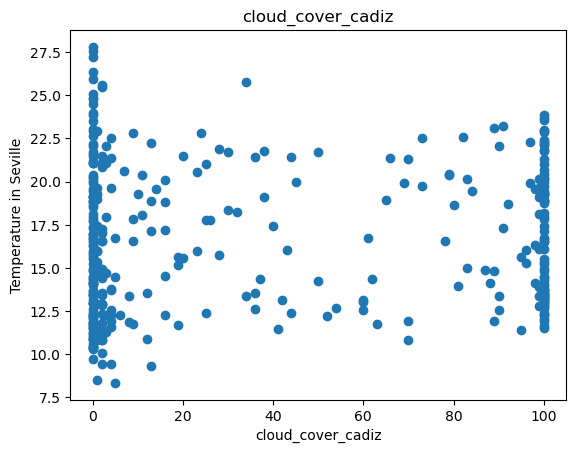

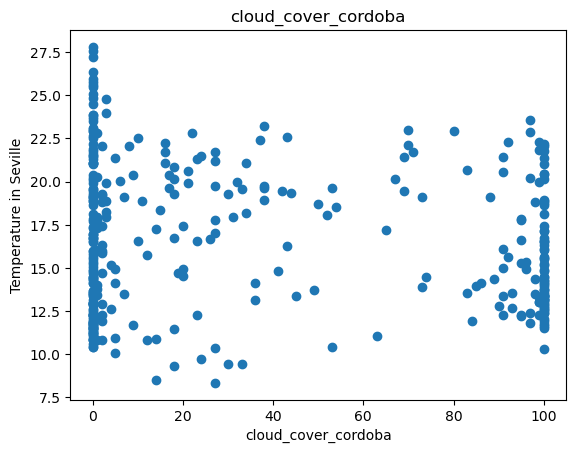

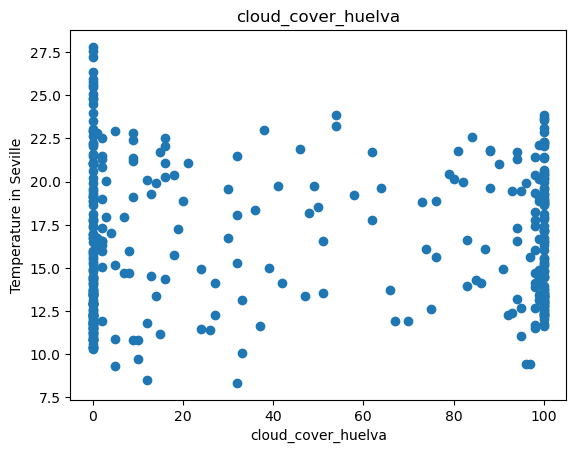

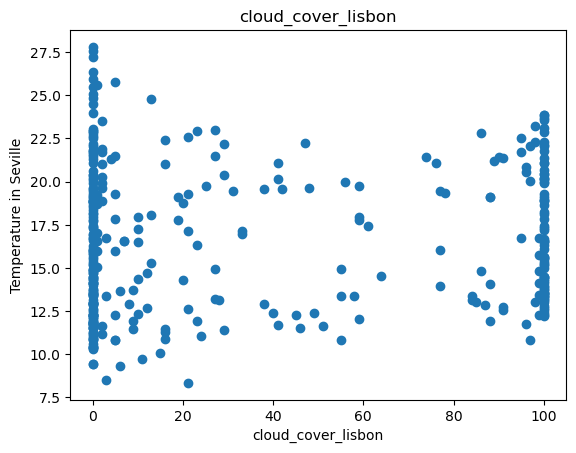

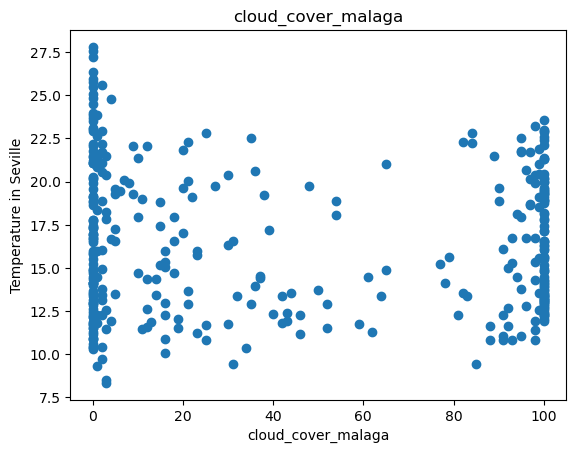

In [83]:
for label in [c for c in wide_temp_data.columns if 'cloud_cover' in c and 'seville' not in c]:
    plt.scatter(wide_temp_data[label], wide_temp_data['temperature_2m_seville'])
    plt.title(label)
    plt.ylabel('Temperature in Seville')
    plt.xlabel(label)
    plt.show()

We can see no direct relation between the variables that we have visualize... but we can have an idea...

### Models

In [84]:
wide_temp_data.index

DatetimeIndex(['2026-03-17 00:00:00+00:00', '2026-03-17 01:00:00+00:00',
               '2026-03-17 02:00:00+00:00', '2026-03-17 03:00:00+00:00',
               '2026-03-17 04:00:00+00:00', '2026-03-17 05:00:00+00:00',
               '2026-03-17 06:00:00+00:00', '2026-03-17 07:00:00+00:00',
               '2026-03-17 08:00:00+00:00', '2026-03-17 09:00:00+00:00',
               ...
               '2026-03-31 14:00:00+00:00', '2026-03-31 15:00:00+00:00',
               '2026-03-31 16:00:00+00:00', '2026-03-31 17:00:00+00:00',
               '2026-03-31 18:00:00+00:00', '2026-03-31 19:00:00+00:00',
               '2026-03-31 20:00:00+00:00', '2026-03-31 21:00:00+00:00',
               '2026-03-31 22:00:00+00:00', '2026-03-31 23:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='date', length=360, freq=None)

In [85]:
nodate_wide_temp_data = wide_temp_data.drop(columns=['datetime'])
shuffle_wide_temp_data = nodate_wide_temp_data.sample(frac=1, random_state=42).reset_index(drop=True)
# sample: just changes the order of the rows 
# frac=1 returns every item,
# random_state is the seed (but it will be useless, because our data updates every day...)
# reset_index(drop=True) to avoid index problems

train, val, test = np.split(shuffle_wide_temp_data, 
                            [int(0.6*len(wide_temp_data)), int(0.8*len(wide_temp_data))])
# Recall the parameters of numpy.split
# first: array
# second: [n,m] it splits the data into three parts, the first one with 60% of the data, the next with 20% and the rest with 20%

/Users/cesarots/anaconda3/envs/ml_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [86]:
target = "temperature_2m_seville"  

y_train = train[target]
X_train = train.drop(columns=[target])

y_val = val[target]
X_val = val.drop(columns=[target])

y_test = test[target]
X_test = test.drop(columns=[target])

### Linear Regression

In [87]:
from sklearn.linear_model import LinearRegression

temp_reg = LinearRegression()
temp_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
print(temp_reg.coef_, temp_reg.intercept_)

[ 1.28898251e-03  8.60303126e-05 -5.85312835e-04 -6.16031710e-03
 -5.81826392e-04 -2.73783355e-03 -2.32534771e-03  1.45299058e-03
 -1.57790524e-01 -2.59616179e-01 -2.57585253e-01  1.63254963e-01
 -1.23595201e-01 -7.42451002e-02  5.04100487e-02  8.79420356e-02
  7.28690756e-02 -4.64458091e-02  3.20302757e-01  1.40279764e-01
 -3.42167928e-02  4.73936379e-02  3.90927460e-02 -5.49766894e-01
  4.92480071e-04  9.35983398e-03 -1.22468661e-03 -1.11881822e-02
  4.85683623e-02  1.04724708e-02  1.70661113e-02 -5.43279446e-02
  1.72446161e-02  1.42561668e-01  7.26409023e-02  1.67511980e-01
  4.97688587e-01  5.63252051e-02  4.05777492e-03  1.00965691e-03
 -6.35109369e-04 -1.38286829e-03  1.56729650e-04 -1.22900599e-03
  5.88548988e-04  2.00548662e-03  9.83346152e-04  1.56312502e-02
  1.08095773e-02  2.22015425e-02 -1.32214633e-02  2.74985179e-02
  1.69292907e-02  1.82490849e-02 -1.82619200e-02  5.76694444e-03
 -3.15586765e-01  3.20749619e-01] 10.453185458512001


Let's focus on the important ones, which are those that their values are bigger (in absolute value):

In [89]:
X_train.columns[np.abs(temp_reg.coef_) > 0.1]

Index(['precipitation_badajoz', 'precipitation_c_real', 'precipitation_cadiz',
       'precipitation_cordoba', 'precipitation_huelva', 'pressure_msl_cadiz',
       'pressure_msl_cordoba', 'pressure_msl_seville', 'temperature_2m_c_real',
       'temperature_2m_cordoba', 'temperature_2m_huelva', 'sin_hour',
       'cos_hour'],
      dtype='object')

In [90]:
temp_reg.score(X_test, y_test) # R^2, coefficient of determination

0.9743997080381294

Let's plot temperature vs time

In [91]:
date_range = pd.date_range(start=wide_temp_data.index.min(),
                           end=wide_temp_data.index.max(),
                           freq="H")

X_plot = pd.DataFrame([X_train.mean()] * len(date_range))

dates = pd.to_datetime(date_range)
X_plot["hour"] = dates.hour
X_plot["dayofweek"] = dates.dayofweek

y_pred = temp_reg.predict(X_plot)

/var/folders/f9/wfy__0w50fs38x4mwcl58q6h0000gn/T/ipykernel_2139/3642132338.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start=wide_temp_data.index.min(),


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- dayofweek


In [ ]:
fig = px.scatter(x=wide_temp_data.index, y=wide_temp_data['temperature_2m_seville'])
fig.add_scatter(x=date_range, y=y_pred, mode='lines', showlegend=False)
fig.show()

Does this make any sense? YES, because we are using MEAN VALUES of the WHOLE dataset, so the prediction will be in the middle of the points. But, for prediction... this model is not really useful. Let's see other model.

### LinearRegression with lag features

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [92]:
temp_target = 'temperature_2m_seville'

# Build the lags
lags = [1, 3, 6, 12, 24]
for lag in lags:
    wide_temp_data[f'temp_lag_{lag}h'] = wide_temp_data[temp_target].shift(lag)

# Rolling means
wide_temp_data['temp_rolling_mean_6h']  = wide_temp_data[temp_target].shift(1).rolling(6).mean()
wide_temp_data['temp_rolling_mean_24h'] = wide_temp_data[temp_target].shift(1).rolling(24).mean()

# Remove NaN
wide_temp_data = wide_temp_data.dropna()

In [ ]:
# Split
cols_to_drop = [temp_target, 'datetime', 'hour']
X = wide_temp_data.drop(columns=cols_to_drop)
y = wide_temp_data[temp_target]

In [95]:
wide_temp_data.columns

Index(['cloud_cover_badajoz', 'cloud_cover_c_real', 'cloud_cover_cadiz',
       'cloud_cover_cordoba', 'cloud_cover_huelva', 'cloud_cover_lisbon',
       'cloud_cover_malaga', 'cloud_cover_seville', 'precipitation_badajoz',
       'precipitation_c_real', 'precipitation_cadiz', 'precipitation_cordoba',
       'precipitation_huelva', 'precipitation_lisbon', 'precipitation_malaga',
       'precipitation_seville', 'pressure_msl_badajoz', 'pressure_msl_c_real',
       'pressure_msl_cadiz', 'pressure_msl_cordoba', 'pressure_msl_huelva',
       'pressure_msl_lisbon', 'pressure_msl_malaga', 'pressure_msl_seville',
       'relative_humidity_2m_badajoz', 'relative_humidity_2m_c_real',
       'relative_humidity_2m_cadiz', 'relative_humidity_2m_cordoba',
       'relative_humidity_2m_huelva', 'relative_humidity_2m_lisbon',
       'relative_humidity_2m_malaga', 'relative_humidity_2m_seville',
       'temperature_2m_badajoz', 'temperature_2m_c_real',
       'temperature_2m_cadiz', 'temperature_2m_cor

MAE:  0.23 °C
RMSE: 0.29 °C
R²:   0.9943


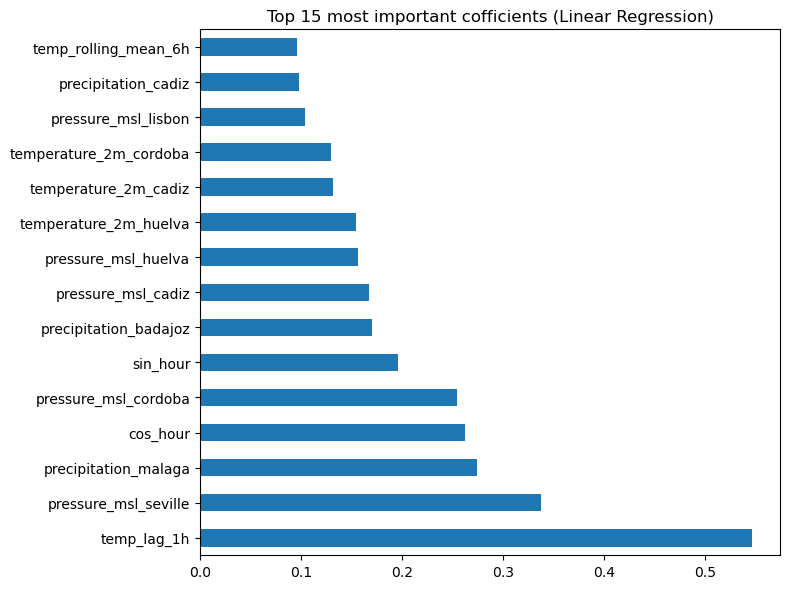

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X, y) # it should be X_train and y_train ... don't forget to do it right on linear_model.py

y_pred_lr = lr_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = root_mean_squared_error(y_test, y_pred_lr)
r2   = r2_score(y_test, y_pred_lr)

print(f"MAE:  {mae:.2f} °C")
print(f"RMSE: {rmse:.2f} °C")
print(f"R²:   {r2:.4f}")

# Coefficients
coefs = pd.Series(lr_model.coef_, index=X_train.columns)
coefs.abs().nlargest(15).plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 most important cofficients (Linear Regression)')
plt.tight_layout()
plt.show()

### XGBoost with lag features

In [173]:
from xgboost import XGBRegressor

In [174]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [175]:
y_pred = xgb_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} °C")
print(f"RMSE: {rmse:.2f} °C")
print(f"R²:   {r2:.4f}")

MAE:  0.53 °C
RMSE: 0.67 °C
R²:   0.9696


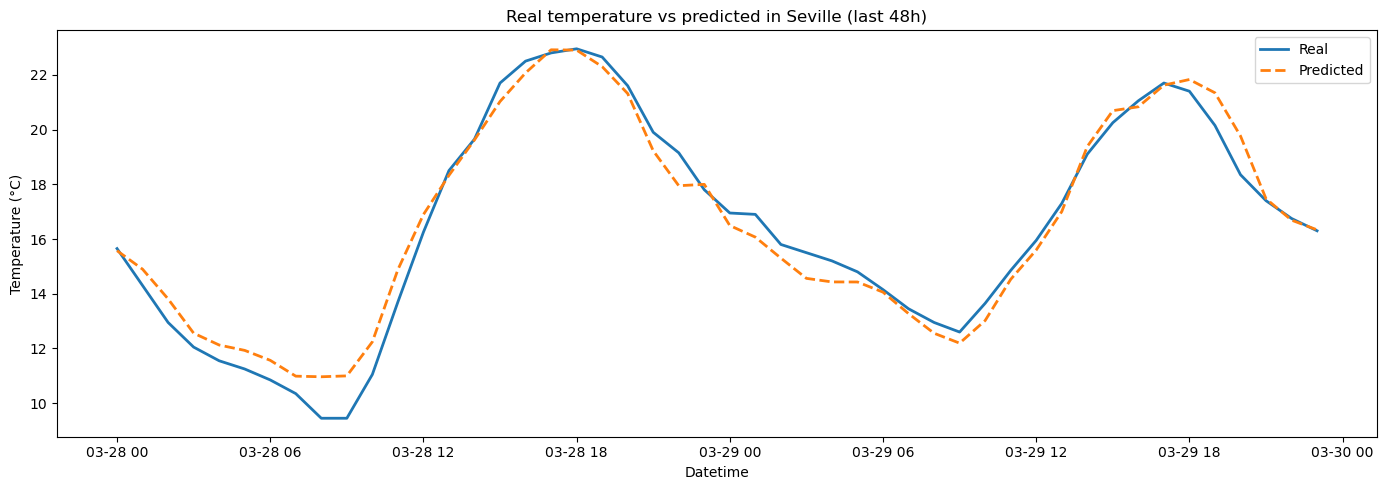

In [176]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label='Real', linewidth=2)
plt.plot(y_test.index, y_pred,        label='Predicted', linewidth=2, linestyle='--')
plt.title('Real temperature vs predicted in Seville (last 48h)')
plt.xlabel('Datetime')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

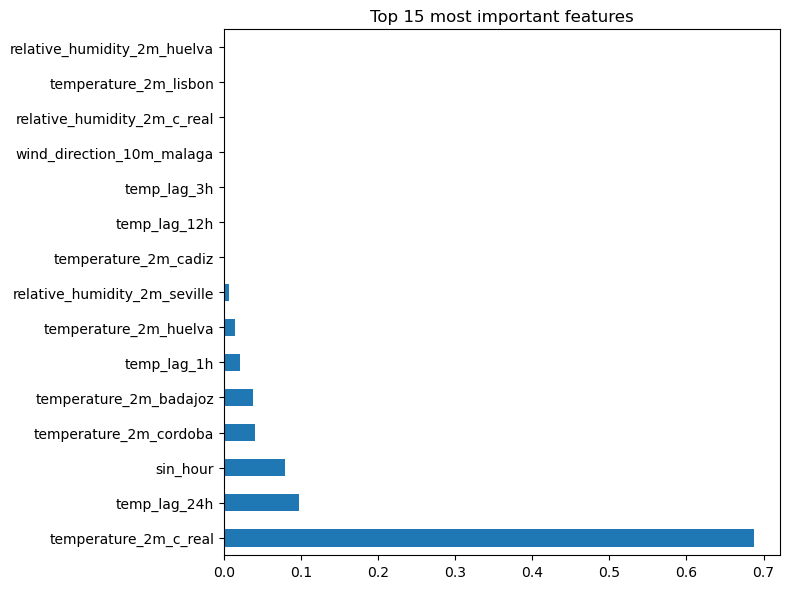

In [177]:
feat_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importance.nlargest(15).plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 most important features')
plt.tight_layout()
plt.show()

### Reflections and ideas

In order to predict the temperature in Seville in the future, we have some options, maybe, we can consider:
* The first one is to build a model for each one of the important features and feature 'datetime', and then we can have all in one with each one of the previous models... For example: if we have temperature T is dependant on $X_1, X_2, X_3,...$, as $T=T(X_1,X_2,X_3,...)$, if we can write $X_i=X_i(datetime)$, then, $T=T(datetime)$ and we will have the temperature related with datetime. This is more like two level prediction:
    1. You train a slight model for each one of the features used in the big model,
    2. You introduce those predictions as inputs in the big model.
* Other option could be: using the temporal features like hour and day of week. But the problem here is that we only have two weeks of data... which is not that much...

## Thoughts on what I have done

There are several options for me to do after all the things I have done here:
* Use all the historic data (2 weeks) to build the model and then compare with the forecast data in order to see how my prediction is...
* Use all the historic data (2 weeks) to build an internal model and test it. Then compare with the predictions in the forecast data

I think the option for me is the first one: use all the historic data to build the model and then compare it with the forecast data.